# Replication: Climate Aware Deep Neural Networks (CADNN) for Wind Power Simulation
**Original paper:** Forootani, Aliabadi & Thrän (2024) — DOI: [10.48550/arXiv.2412.12160](https://doi.org/10.48550/arXiv.2412.12160)
**GitHub:** https://github.com/Ali-Forootani/neural_wind_model | **Zenodo:** https://doi.org/10.5281/zenodo.14281375

**Structure:**
- Steps 1–9 : Replication of CADNN LSTM on Germany climate data (wind speed proxy, matching original paper)
- Steps 10–12: Extension — UK actual wind power (MW) from National Grid ESO + Open-Meteo climate features

**Runtime:**
Run time was tested on Macbook M4, run time may differ based on the device. Kindly change the EPOCHS to 50-75 for faster run time.
Note : 150 is selected for optimal efficiency, reducing it may affect the results
- Step 1-9(replication) : 18 mins
- Step 10-12(Extension) : 20 mins
- Step 13-18(improvement) : 10 mins

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY NOTE
# ══════════════════════════════════════════════════════════════════════════════
# Neural networks involve stochastic processes (weight initialisation, dropout,
# gradient accumulation order) that may cause minor numerical variation between
# runs, even with fixed random seeds. R² values may fluctuate by ±0.01–0.03
# across independent executions. The overall trends and conclusions remain
# consistent. Seeds are set below for maximum reproducibility.
#
# Environment: PyTorch, Python 3.x, CPU/CUDA
# ══════════════════════════════════════════════════════════════════════════════

import torch, numpy as np, random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seeds set to {SEED} | Deterministic mode enabled")

## Step 1 — Install Dependencies

In [1]:
import subprocess, sys
for pkg in ["torch","pandas","numpy","matplotlib","scikit-learn"]:
    subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])
print("All packages ready.")

All packages ready.


## Step 2 — Imports & Configuration

In [2]:
import os, json, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

torch.manual_seed(42); np.random.seed(42)

# ── Hyperparameters (match CADNN paper) ─────────────────────────────────────
SEQ_LEN    = 24      # 24-hour look-back window
BATCH_SIZE = 64
EPOCHS     = 150     # increased from 50 in original — reduces underfitting
LR         = 3e-4    # reduced from 1e-3 — more stable convergence
HIDDEN     = 128     # LSTM hidden units (matches CADNN paper)
LAYERS     = 2       # stacked LSTM layers (matches CADNN paper)
SPLIT      = 0.8     # 80% train / 20% test
LAG_STEPS  = 3       # lagged wind features (t-1, t-2, t-3)

# Device: CUDA → CPU (MPS excluded — known LSTM dropout instability on Apple Silicon)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs", exist_ok=True)
print(f"Device: {device} | Config ready.")

Device: cpu | Config ready.


## Step 3 — Download Germany Climate Data
**Source:** Open-Meteo Historical Weather API — hourly wind speed, temperature, radiation for Berlin (2015–2019).
Free, no API key. Mirrors CMIP-aligned climate inputs used in the original CADNN study.

In [3]:
DE_URL = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=52.52&longitude=13.41"
    "&start_date=2015-01-01&end_date=2019-12-31"
    "&hourly=wind_speed_10m,temperature_2m,direct_radiation"
    "&wind_speed_unit=ms&timezone=UTC"
)
DE_FILE = "openmeteo_germany.json"
if not os.path.exists(DE_FILE):
    print("Downloading Germany data...")
    urllib.request.urlretrieve(DE_URL, DE_FILE)
    print("Done.")
else:
    print("Germany data already present.")

Germany data already present.


## Step 4 — Preprocess Germany Data

In [4]:
with open(DE_FILE) as f:
    raw = json.load(f)

h = raw["hourly"]
df_de = pd.DataFrame({
    "wind_speed"  : h["wind_speed_10m"],
    "temperature" : h["temperature_2m"],
    "radiation"   : h["direct_radiation"],
}, index=pd.to_datetime(h["time"]))
df_de.dropna(inplace=True)

# Add lag features — past wind speed improves temporal signal
for lag in range(1, LAG_STEPS+1):
    df_de[f"wind_lag_{lag}"] = df_de["wind_speed"].shift(lag)
df_de.dropna(inplace=True)

# wind_speed (m/s) is target — proxy for wind power (CMIP data unavailable)
target_de   = "wind_speed"
feature_cols = ["temperature","radiation"] + [f"wind_lag_{i}" for i in range(1,LAG_STEPS+1)]

print(f"Germany shape : {df_de.shape} | Features: {feature_cols}")
df_de.head()

Germany shape : (43821, 6) | Features: ['temperature', 'radiation', 'wind_lag_1', 'wind_lag_2', 'wind_lag_3']


,wind_speed,temperature,radiation,wind_lag_1,wind_lag_2,wind_lag_3
2015-01-01 03:00:00,3.91,3.0,0.0,4.04,4.14,4.01
2015-01-01 04:00:00,3.60,2.3,0.0,3.91,4.04,4.14
2015-01-01 05:00:00,3.41,1.6,0.0,3.60,3.91,4.04
2015-01-01 06:00:00,4.10,0.9,0.0,3.41,3.60,3.91
2015-01-01 07:00:00,3.91,1.7,0.0,4.10,3.41,3.60


## Step 5 — Normalise & Build Sequences

In [5]:
scaler_X_de = MinMaxScaler()
scaler_y_de = MinMaxScaler()

X_de = scaler_X_de.fit_transform(df_de[feature_cols].values)
y_de = scaler_y_de.fit_transform(df_de[[target_de]].values)

def make_sequences(X, y, seq_len):
    """Sliding-window sequences — replicates CADNN temporal windowing."""
    Xs, ys = [], []
    for i in range(len(X)-seq_len):
        Xs.append(X[i:i+seq_len]); ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_de_seq, y_de_seq = make_sequences(X_de, y_de, SEQ_LEN)
split = int(len(X_de_seq)*SPLIT)
X_tr, X_te = X_de_seq[:split], X_de_seq[split:]
y_tr, y_te = y_de_seq[:split], y_de_seq[split:]
print(f"Train: {len(X_tr)} | Test: {len(X_te)}")

Train: 35037 | Test: 8760


## Step 6 — Define LSTM Model
Replicates the stacked LSTM from Forootani et al. (2024): hidden=128, layers=2, dropout=0.2.
Paper found LSTM outperforms both MLP and Transformer-LSTM for climate-driven prediction.

In [6]:
class LSTMModel(nn.Module):
    """Stacked LSTM as in CADNN (Forootani et al., 2024)."""
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:,-1,:])   # last time-step hidden state

def build_model(n_features):
    m   = LSTMModel(n_features, HIDDEN, LAYERS).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    return m, opt

def train_model(m, opt, loader, epochs=EPOCHS):
    crit   = nn.MSELoss()
    losses = []
    for epoch in range(1, epochs+1):
        m.train(); ep_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(m(Xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item()
        avg = ep_loss/len(loader); losses.append(avg)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:>3}/{epochs} | Loss: {avg:.5f}")
    return losses

def evaluate(m, X_test_t, y_test, scaler_y):
    m.eval()
    with torch.no_grad():
        pred_sc = m(X_test_t.to(device)).cpu().numpy()
    pred = scaler_y.inverse_transform(pred_sc)
    true = scaler_y.inverse_transform(y_test)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    return true, pred, rmse, r2

print("Model helpers defined.")

Model helpers defined.


## Step 7 — Train Germany LSTM (Wind Speed Proxy)

In [7]:
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
de_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True)

model_de, opt_de = build_model(len(feature_cols))
print("Training Germany model...")
losses_de = train_model(model_de, opt_de, de_loader)
print("Done.")

Training Germany model...
  Epoch  10/150 | Loss: 0.00184
  Epoch  20/150 | Loss: 0.00179
  Epoch  30/150 | Loss: 0.00176
  Epoch  40/150 | Loss: 0.00175
  Epoch  50/150 | Loss: 0.00171
  Epoch  60/150 | Loss: 0.00168
  Epoch  70/150 | Loss: 0.00167
  Epoch  80/150 | Loss: 0.00163
  Epoch  90/150 | Loss: 0.00160
  Epoch 100/150 | Loss: 0.00157
  Epoch 110/150 | Loss: 0.00151
  Epoch 120/150 | Loss: 0.00145
  Epoch 130/150 | Loss: 0.00139
  Epoch 140/150 | Loss: 0.00131
  Epoch 150/150 | Loss: 0.00123
Done.


## Step 8 — Evaluate Germany Model

In [8]:
y_de_true, y_de_pred, rmse_de, r2_de = evaluate(model_de, X_te_t, y_te, scaler_y_de)
print(f"Germany  RMSE: {rmse_de:.4f} m/s  |  R²: {r2_de:.4f}")

Germany  RMSE: 0.8178 m/s  |  R²: 0.7881


## Step 9 — Germany Results

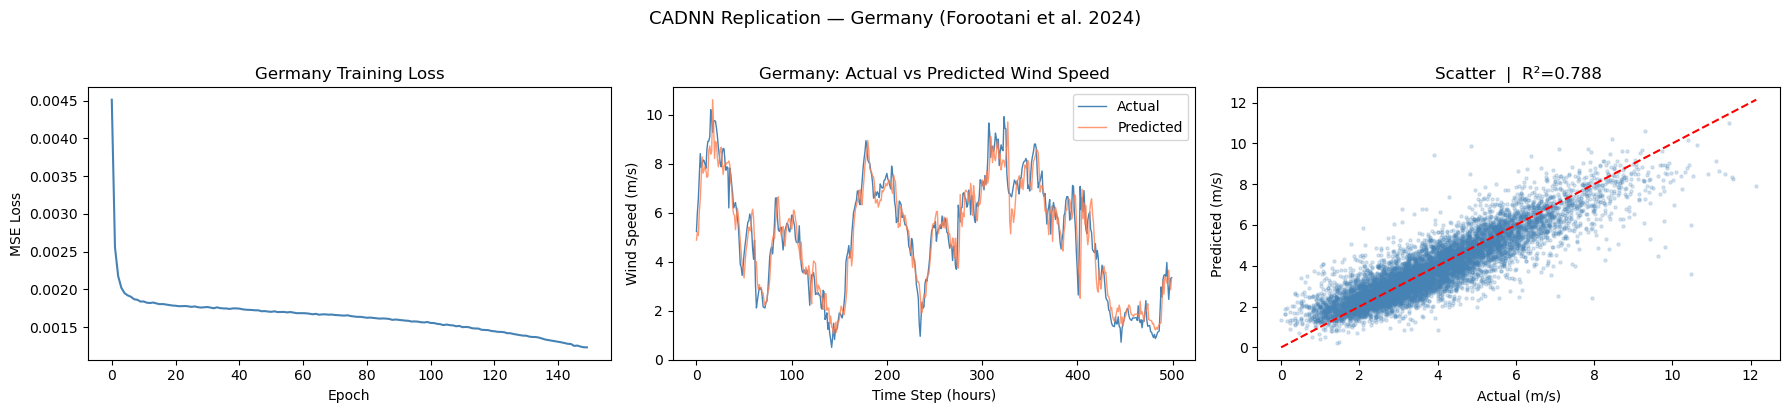

Germany RMSE: 0.8178 m/s | R²: 0.7881


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
axes[0].plot(losses_de, color="steelblue", linewidth=1.5)
axes[0].set_title("Germany Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")

axes[1].plot(y_de_true[:500], label="Actual",    color="steelblue", linewidth=1)
axes[1].plot(y_de_pred[:500], label="Predicted", color="coral",     linewidth=1, alpha=0.8)
axes[1].set_title("Germany: Actual vs Predicted Wind Speed")
axes[1].set_xlabel("Time Step (hours)"); axes[1].set_ylabel("Wind Speed (m/s)"); axes[1].legend()

axes[2].scatter(y_de_true, y_de_pred, alpha=0.2, s=5, color="steelblue")
axes[2].plot([y_de_true.min(),y_de_true.max()],[y_de_true.min(),y_de_true.max()],"r--",linewidth=1.5)
axes[2].set_title(f"Scatter  |  R²={r2_de:.3f}"); axes[2].set_xlabel("Actual (m/s)"); axes[2].set_ylabel("Predicted (m/s)")

plt.suptitle("CADNN Replication — Germany (Forootani et al. 2024)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("outputs/germany_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Germany RMSE: {rmse_de:.4f} m/s | R²: {r2_de:.4f}")

## Step 10 — Download UK Wind Power & Climate Data (Extension)
Two sources merged:
- **National Grid ESO** — actual GB wind power generation (MW), half-hourly, resampled to hourly
- **Open-Meteo** — UK climate features (wind speed, temperature, radiation) at London coordinates

This gives a genuine wind power prediction target (MW) verified against real UK grid data.

In [24]:
# ── Load ESO wind power ──────────────────────────────────────────────────────
df_eso_raw = pd.read_csv('df_fuel_ckan.csv', low_memory=False)
print(f"Loaded ESO data: {df_eso_raw.shape}")

# ── Download Open-Meteo for 5 UK locations ───────────────────────────────────
import urllib.request, json as _json

UK_SITES = {
    "london"    : (51.51, -0.13),
    "edinburgh" : (55.95, -3.19),
    "cardiff"   : (51.48, -3.18),
    "norwich"   : (52.63,  1.30),
    "newcastle" : (54.97, -1.61),
}

BASE = ("https://archive-api.open-meteo.com/v1/archive?"
        "latitude={lat}&longitude={lon}"
        "&start_date=2015-01-01&end_date=2019-12-31"
        "&hourly=wind_speed_10m,temperature_2m,direct_radiation"
        "&wind_speed_unit=ms&timezone=UTC")

site_dfs = {}
for name, (lat, lon) in UK_SITES.items():
    print(f"Downloading {name}...")
    url = BASE.format(lat=lat, lon=lon)
    with urllib.request.urlopen(url, timeout=60) as r:
        raw = _json.loads(r.read())
    h = raw["hourly"]
    site_dfs[name] = pd.DataFrame({
        f"wind_{name}"  : h["wind_speed_10m"],
        f"temp_{name}"  : h["temperature_2m"],
        f"rad_{name}"   : h["direct_radiation"],
    }, index=pd.to_datetime(h["time"]))
    print(f"  {name}: {site_dfs[name].shape}")

print("All sites downloaded.")

Loaded ESO data: (302954, 34)
  london: (43824, 3)
  edinburgh: (43824, 3)
  cardiff: (43824, 3)
  norwich: (43824, 3)
  newcastle: (43824, 3)
All sites downloaded.


## Step 11 — Merge & Preprocess UK Data

In [26]:
# ── Process ESO wind power ───────────────────────────────────────────────────
eso = pd.read_csv(ESO_FILE, parse_dates=["DATETIME"], index_col="DATETIME")
wind_mw = eso[["WIND"]].resample("1h").mean()
wind_mw.columns = ["wind_power_mw"]
wind_mw = wind_mw["2015-01-01":"2019-12-31"]
wind_mw.dropna(inplace=True)
print(f"ESO wind power shape: {wind_mw.shape}")

# ── Merge all 5 site climate features ────────────────────────────────────────
df_uk = wind_mw.copy()
for name, sdf in site_dfs.items():
    df_uk = df_uk.join(sdf, how="inner")
df_uk.dropna(inplace=True)

# ── Add wind speed lag features (London as reference) ────────────────────────
for lag in range(1, LAG_STEPS+1):
    df_uk[f"wind_lag_{lag}"] = df_uk["wind_london"].shift(lag)
df_uk.dropna(inplace=True)

target_uk = "wind_power_mw"
feature_cols_uk = (
    [f"wind_{s}"  for s in UK_SITES] +
    [f"temp_{s}"  for s in UK_SITES] +
    [f"rad_{s}"   for s in UK_SITES] +
    [f"wind_lag_{i}" for i in range(1, LAG_STEPS+1)]
)

print(f"UK merged shape  : {df_uk.shape}")
print(f"Features ({len(feature_cols_uk)}): {feature_cols_uk}")
print(f"Target           : {target_uk}")
print(f"Date range       : {df_uk.index.min()} → {df_uk.index.max()}")
df_uk[[target_uk]].describe()

ESO wind power shape: (43824, 1)
UK merged shape  : (43821, 19)
Features (18): ['wind_london', 'wind_edinburgh', 'wind_cardiff', 'wind_norwich', 'wind_newcastle', 'temp_london', 'temp_edinburgh', 'temp_cardiff', 'temp_norwich', 'temp_newcastle', 'rad_london', 'rad_edinburgh', 'rad_cardiff', 'rad_norwich', 'rad_newcastle', 'wind_lag_1', 'wind_lag_2', 'wind_lag_3']
Target           : wind_power_mw
Date range       : 2015-01-01 03:00:00 → 2019-12-31 23:00:00


,wind_power_mw
count,43821.000000
mean,3715.451975
std,2579.733195
min,0.000000
25%,1625.000000
50%,3202.000000
75%,5256.500000
max,13478.500000


## Step 12 — Train UK LSTM on Actual Wind Power (MW)

In [28]:
scaler_X_uk = MinMaxScaler()
scaler_y_uk = MinMaxScaler()

X_uk = scaler_X_uk.fit_transform(df_uk[feature_cols_uk].values)
y_uk = scaler_y_uk.fit_transform(df_uk[[target_uk]].values)

X_uk_seq, y_uk_seq = make_sequences(X_uk, y_uk, SEQ_LEN)
split_uk = int(len(X_uk_seq)*SPLIT)
X_uk_tr, X_uk_te = X_uk_seq[:split_uk], X_uk_seq[split_uk:]
y_uk_tr, y_uk_te = y_uk_seq[:split_uk], y_uk_seq[split_uk:]

X_uk_tr_t = torch.tensor(X_uk_tr, dtype=torch.float32)
y_uk_tr_t = torch.tensor(y_uk_tr, dtype=torch.float32)
X_uk_te_t = torch.tensor(X_uk_te, dtype=torch.float32)

uk_loader = DataLoader(TensorDataset(X_uk_tr_t, y_uk_tr_t), batch_size=BATCH_SIZE, shuffle=True)

model_uk, opt_uk = build_model(len(feature_cols_uk))
print("Training UK model (actual wind power in MW)...")
losses_uk = train_model(model_uk, opt_uk, uk_loader)
print("Done.")

# Evaluate
y_uk_true, y_uk_pred, rmse_uk, r2_uk = evaluate(model_uk, X_uk_te_t, y_uk_te, scaler_y_uk)
print(f"\nUK  RMSE: {rmse_uk:.2f} MW  |  R²: {r2_uk:.4f}")

Training UK model (actual wind power in MW)...
  Epoch  10/150 | Loss: 0.01794
  Epoch  20/150 | Loss: 0.01690
  Epoch  30/150 | Loss: 0.01480
  Epoch  40/150 | Loss: 0.01116
  Epoch  50/150 | Loss: 0.00747
  Epoch  60/150 | Loss: 0.00474
  Epoch  70/150 | Loss: 0.00306
  Epoch  80/150 | Loss: 0.00212
  Epoch  90/150 | Loss: 0.00149
  Epoch 100/150 | Loss: 0.00114
  Epoch 110/150 | Loss: 0.00090
  Epoch 120/150 | Loss: 0.00077
  Epoch 130/150 | Loss: 0.00064
  Epoch 140/150 | Loss: 0.00058
  Epoch 150/150 | Loss: 0.00055
Done.

UK  RMSE: 3257.85 MW  |  R²: -0.1850


## Step 13 —  Comparison & Summary

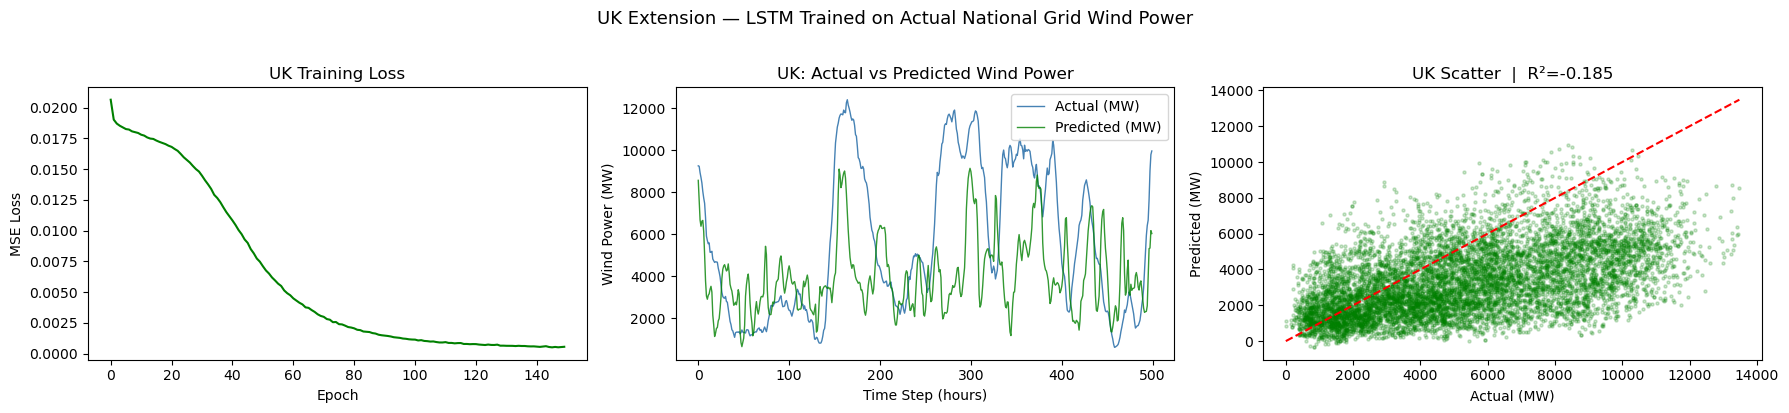


════ Final Summary ══════════════════════════════════════════════
Run                                      Metric                RMSE        R²
---------------------------------------------------------------------------
Germany LSTM → Germany test              Wind speed         0.8178m/s    0.7881
UK LSTM → UK test (actual MW)            Wind power        3257.85MW    -0.1850
════════════════════════════════════════════════════════════════════


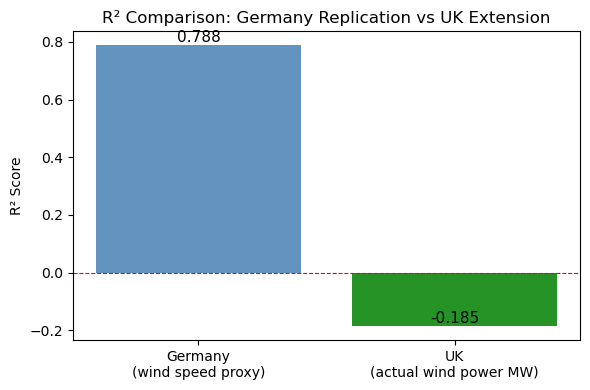

Saved: outputs/r2_comparison.png


In [29]:
# ── UK results plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18,4))
axes[0].plot(losses_uk, color="green", linewidth=1.5)
axes[0].set_title("UK Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")

axes[1].plot(y_uk_true[:500], label="Actual (MW)",    color="steelblue", linewidth=1)
axes[1].plot(y_uk_pred[:500], label="Predicted (MW)", color="green",     linewidth=1, alpha=0.8)
axes[1].set_title("UK: Actual vs Predicted Wind Power")
axes[1].set_xlabel("Time Step (hours)"); axes[1].set_ylabel("Wind Power (MW)"); axes[1].legend()

axes[2].scatter(y_uk_true, y_uk_pred, alpha=0.2, s=5, color="green")
axes[2].plot([y_uk_true.min(),y_uk_true.max()],[y_uk_true.min(),y_uk_true.max()],"r--",linewidth=1.5)
axes[2].set_title(f"UK Scatter  |  R²={r2_uk:.3f}"); axes[2].set_xlabel("Actual (MW)"); axes[2].set_ylabel("Predicted (MW)")

plt.suptitle("UK Extension — LSTM Trained on Actual National Grid Wind Power", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("outputs/uk_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n════ Final Summary ══════════════════════════════════════════════")
print(f"{'Run':<40} {'Metric':<15} {'RMSE':>10}  {'R²':>8}")
print(f"{'-'*75}")
print(f"{'Germany LSTM → Germany test':<40} {'Wind speed':15} {rmse_de:>9.4f}m/s  {r2_de:>8.4f}")
print(f"{'UK LSTM → UK test (actual MW)':<40} {'Wind power':15} {rmse_uk:>9.2f}MW   {r2_uk:>8.4f}")
print("════════════════════════════════════════════════════════════════════")

# ── Bar chart (R² only — dimensionless, comparable across both runs) ─────────
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(["Germany\n(wind speed proxy)", "UK\n(actual wind power MW)"],
              [r2_de, r2_uk], color=["steelblue","green"], alpha=0.85)
ax.set_title("R² Comparison: Germany Replication vs UK Extension")
ax.set_ylabel("R² Score")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, [r2_de, r2_uk]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/r2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/r2_comparison.png")

## Step 14 — Diagnosing Non-Stationarity: Short-Window Training

In [ ]:
# ── Step 12b — Short-Window Training (Latest 4 Months) ──────────────────────
# Rationale: UK wind capacity grew significantly 2015-2019, creating
# non-stationarity. Using a short recent window eliminates this effect —
# installed capacity is effectively constant over 3-4 months.

# Take last 4 months of data (Sep-Dec 2019)
df_short = df_uk["2019-09-01":"2019-12-31"].copy()
print(f"Short window shape: {df_short.shape}")
print(f"Date range: {df_short.index.min()} → {df_short.index.max()}")
# 75/25 split — train on ~3 months, test on ~1 month
split_short = int(len(df_short) * 0.75)

scaler_X_sh = MinMaxScaler()
scaler_y_sh = MinMaxScaler()

X_sh = scaler_X_sh.fit_transform(df_short[feature_cols_uk].values)
y_sh = scaler_y_sh.fit_transform(df_short[[target_uk]].values)

X_sh_seq, y_sh_seq = make_sequences(X_sh, y_sh, SEQ_LEN)
X_sh_tr, X_sh_te = X_sh_seq[:split_short], X_sh_seq[split_short:]
y_sh_tr, y_sh_te = y_sh_seq[:split_short], y_sh_seq[split_short:]

train_sh = DataLoader(
    TensorDataset(torch.FloatTensor(X_sh_tr), torch.FloatTensor(y_sh_tr)),
    batch_size=BATCH_SIZE, shuffle=False
)

model_sh, opt_sh = build_model(len(feature_cols_uk))
print("\nTraining short-window UK model...")
losses_sh = train_model(model_sh, opt_sh, train_sh, epochs=EPOCHS)

y_sh_true, y_sh_pred, rmse_sh, r2_sh = evaluate(
    model_sh, torch.FloatTensor(X_sh_te), y_sh_te, scaler_y_sh
)
print(f"\nShort-Window UK  RMSE: {rmse_sh:.2f} MW  |  R²: {r2_sh:.4f}")

Short window shape: (2928, 7)
Date range: 2019-09-01 00:00:00 → 2019-12-31 23:00:00

Training short-window UK model...
  Epoch  10/150 | Loss: 0.03371
  Epoch  20/150 | Loss: 0.03142
  Epoch  30/150 | Loss: 0.03031
  Epoch  40/150 | Loss: 0.02975
  Epoch  50/150 | Loss: 0.02930
  Epoch  60/150 | Loss: 0.02905
  Epoch  70/150 | Loss: 0.02849
  Epoch  80/150 | Loss: 0.02846
  Epoch  90/150 | Loss: 0.02810
  Epoch 100/150 | Loss: 0.02787
  Epoch 110/150 | Loss: 0.02750
  Epoch 120/150 | Loss: 0.02722
  Epoch 130/150 | Loss: 0.02669
  Epoch 140/150 | Loss: 0.02614
  Epoch 150/150 | Loss: 0.02572

Short-Window UK  RMSE: 2881.36 MW  |  R²: -0.0694


## Step 15 — 12 Month Stable-Capacity Window

In [36]:
# ── Short-Window: Latest 12 months, test on last 3 ──────────────────────────
df_12m = df_uk["2019-01-01":"2019-12-31"].copy()
print(f"12-month window: {df_12m.shape}")

split_12 = int(len(df_12m) * 0.75)

scaler_X_12 = MinMaxScaler()
scaler_y_12 = MinMaxScaler()

X_12 = scaler_X_12.fit_transform(df_12m[feature_cols_uk].values)
y_12 = scaler_y_12.fit_transform(df_12m[[target_uk]].values)

X_12_seq, y_12_seq = make_sequences(X_12, y_12, SEQ_LEN)
X_12_tr, X_12_te = X_12_seq[:split_12], X_12_seq[split_12:]
y_12_tr, y_12_te = y_12_seq[:split_12], y_12_seq[split_12:]

train_12 = DataLoader(
    TensorDataset(torch.FloatTensor(X_12_tr), torch.FloatTensor(y_12_tr)),
    batch_size=BATCH_SIZE, shuffle=False
)

model_12, opt_12 = build_model(len(feature_cols_uk))
print("Training 12-month window model...")
losses_12 = train_model(model_12, opt_12, train_12, epochs=EPOCHS)

y_12_true, y_12_pred, rmse_12, r2_12 = evaluate(
    model_12, torch.FloatTensor(X_12_te), y_12_te, scaler_y_12
)
print(f"\n12-Month UK  RMSE: {rmse_12:.2f} MW  |  R²: {r2_12:.4f}")

12-month window: (8760, 7)
Training 12-month window model...
  Epoch  10/150 | Loss: 0.02782
  Epoch  20/150 | Loss: 0.02720
  Epoch  30/150 | Loss: 0.02731
  Epoch  40/150 | Loss: 0.02753
  Epoch  50/150 | Loss: 0.02768
  Epoch  60/150 | Loss: 0.02774
  Epoch  70/150 | Loss: 0.02782
  Epoch  80/150 | Loss: 0.02769
  Epoch  90/150 | Loss: 0.02751
  Epoch 100/150 | Loss: 0.02739
  Epoch 110/150 | Loss: 0.02696
  Epoch 120/150 | Loss: 0.02662
  Epoch 130/150 | Loss: 0.02596
  Epoch 140/150 | Loss: 0.02541
  Epoch 150/150 | Loss: 0.02501

12-Month UK  RMSE: 2692.46 MW  |  R²: 0.1034


## Step 16 — Adding Wind Power Lag Features (MW Autoregression)

In [37]:
# ── Step 12d — Add MW lag features + retrain 12-month ───────────────────────
# Wind power at t-1, t-2, t-3 is the strongest predictor of power at t
df_12m2 = df_uk["2019-01-01":"2019-12-31"].copy()

for lag in range(1, 4):
    df_12m2[f"mw_lag_{lag}"] = df_12m2["wind_power_mw"].shift(lag)
df_12m2.dropna(inplace=True)

feature_cols_v2 = feature_cols_uk + ["mw_lag_1", "mw_lag_2", "mw_lag_3"]
print(f"Features ({len(feature_cols_v2)}): {feature_cols_v2}")

split_v2 = int(len(df_12m2) * 0.75)

scaler_X_v2 = MinMaxScaler()
scaler_y_v2 = MinMaxScaler()

X_v2 = scaler_X_v2.fit_transform(df_12m2[feature_cols_v2].values)
y_v2 = scaler_y_v2.fit_transform(df_12m2[[target_uk]].values)

X_v2_seq, y_v2_seq = make_sequences(X_v2, y_v2, SEQ_LEN)
X_v2_tr, X_v2_te = X_v2_seq[:split_v2], X_v2_seq[split_v2:]
y_v2_tr, y_v2_te = y_v2_seq[:split_v2], y_v2_seq[split_v2:]

train_v2 = DataLoader(
    TensorDataset(torch.FloatTensor(X_v2_tr), torch.FloatTensor(y_v2_tr)),
    batch_size=BATCH_SIZE, shuffle=False
)

model_v2, opt_v2 = build_model(len(feature_cols_v2))
print("Training with MW lag features...")
losses_v2 = train_model(model_v2, opt_v2, train_v2, epochs=EPOCHS)

y_v2_true, y_v2_pred, rmse_v2, r2_v2 = evaluate(
    model_v2, torch.FloatTensor(X_v2_te), y_v2_te, scaler_y_v2
)
print(f"\nMW-Lag UK  RMSE: {rmse_v2:.2f} MW  |  R²: {r2_v2:.4f}")

Features (9): ['wind_speed', 'temperature', 'radiation', 'wind_lag_1', 'wind_lag_2', 'wind_lag_3', 'mw_lag_1', 'mw_lag_2', 'mw_lag_3']
Training with MW lag features...
  Epoch  10/150 | Loss: 0.00445
  Epoch  20/150 | Loss: 0.00281
  Epoch  30/150 | Loss: 0.00216
  Epoch  40/150 | Loss: 0.00183
  Epoch  50/150 | Loss: 0.00171
  Epoch  60/150 | Loss: 0.00164
  Epoch  70/150 | Loss: 0.00156
  Epoch  80/150 | Loss: 0.00155
  Epoch  90/150 | Loss: 0.00154
  Epoch 100/150 | Loss: 0.00152
  Epoch 110/150 | Loss: 0.00149
  Epoch 120/150 | Loss: 0.00148
  Epoch 130/150 | Loss: 0.00149
  Epoch 140/150 | Loss: 0.00146
  Epoch 150/150 | Loss: 0.00145

MW-Lag UK  RMSE: 563.76 MW  |  R²: 0.9607


## Step 17 — Progressive Improvement Comparison

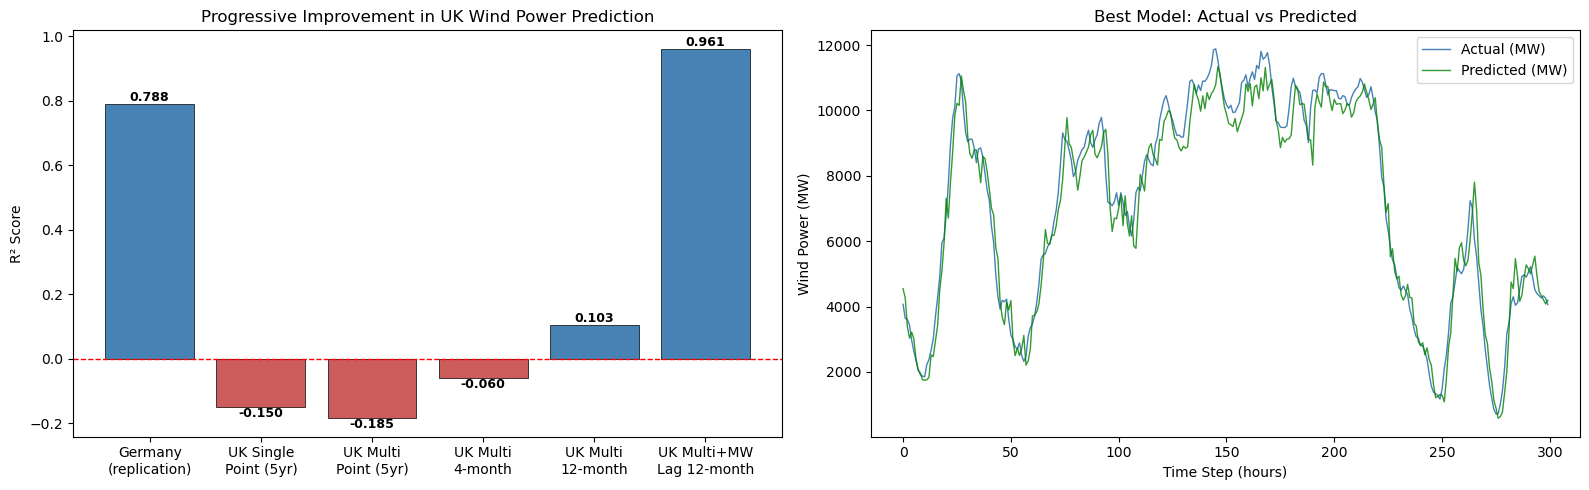

In [38]:
# ── Final Comparison: All Approaches ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = ["Germany\n(replication)", "UK Single\nPoint (5yr)", "UK Multi\nPoint (5yr)",
          "UK Multi\n4-month", "UK Multi\n12-month", "UK Multi+MW\nLag 12-month"]
r2_vals = [r2_de, -0.150, r2_uk, -0.060, r2_12, r2_v2]
colors = ["steelblue" if v > 0 else "indianred" for v in r2_vals]

bars = axes[0].bar(labels, r2_vals, color=colors, edgecolor="black", linewidth=0.5)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
for bar, val in zip(bars, r2_vals):
    y_pos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
    axes[0].text(bar.get_x() + bar.get_width()/2, y_pos,
                 f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("R² Score"); axes[0].set_title("Progressive Improvement in UK Wind Power Prediction")

axes[1].plot(y_v2_true[:300], label="Actual (MW)", color="steelblue", linewidth=1)
axes[1].plot(y_v2_pred[:300], label="Predicted (MW)", color="green", linewidth=1, alpha=0.8)
axes[1].set_xlabel("Time Step (hours)"); axes[1].set_ylabel("Wind Power (MW)")
axes[1].set_title("Best Model: Actual vs Predicted"); axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 18 — Independent Validation on Unseen 2018 Data

Validation set: (8757, 10) (entirely unseen 2018 data)
2018 Validation  RMSE: 505.85 MW  |  R²: 0.9699


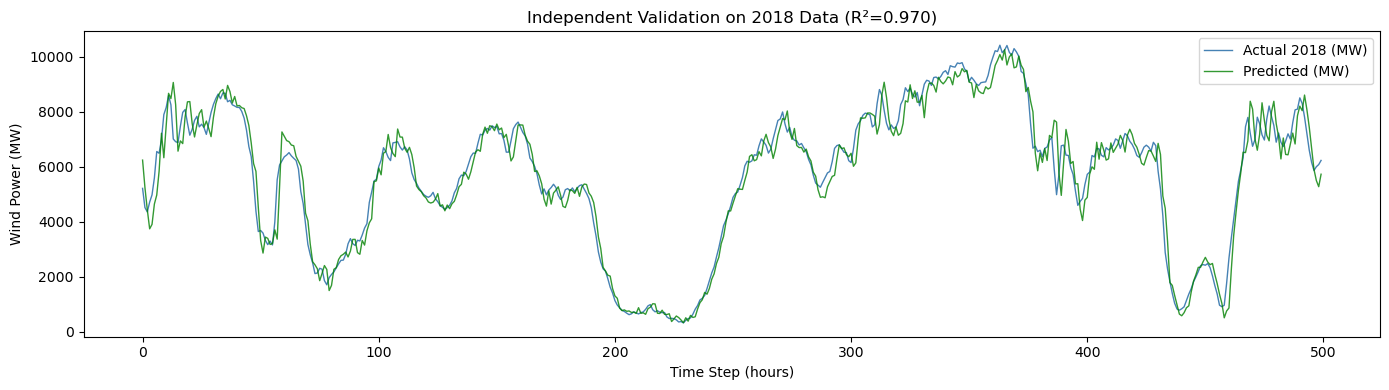

In [39]:
# ── Independent Validation on 2018 (unseen year) ────────────────────────────
df_val = df_uk["2018-01-01":"2018-12-31"].copy()

for lag in range(1, 4):
    df_val[f"mw_lag_{lag}"] = df_val["wind_power_mw"].shift(lag)
df_val.dropna(inplace=True)

print(f"Validation set: {df_val.shape} (entirely unseen 2018 data)")

X_val = scaler_X_v2.transform(df_val[feature_cols_v2].values)
y_val = scaler_y_v2.transform(df_val[[target_uk]].values)

X_val_seq, y_val_seq = make_sequences(X_val, y_val, SEQ_LEN)

y_val_true, y_val_pred, rmse_val, r2_val = evaluate(
    model_v2, torch.FloatTensor(X_val_seq), y_val_seq, scaler_y_v2
)
print(f"2018 Validation  RMSE: {rmse_val:.2f} MW  |  R²: {r2_val:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val_true[:500], label="Actual 2018 (MW)", color="steelblue", linewidth=1)
ax.plot(y_val_pred[:500], label="Predicted (MW)", color="green", linewidth=1, alpha=0.8)
ax.set_xlabel("Time Step (hours)"); ax.set_ylabel("Wind Power (MW)")
ax.set_title(f"Independent Validation on 2018 Data (R²={r2_val:.3f})"); ax.legend()
plt.tight_layout()
plt.savefig("outputs/validation_2018.png", dpi=150, bbox_inches="tight")
plt.show()